In [1]:
import numpy as np
import pandas as pd
import keras
import cv2
from matplotlib import pyplot as plt
import os
import random
from PIL import Image

In [2]:
df = pd.read_csv("train.csv")
base_path="./images/"

In [3]:
df

,id,url,landmark_id
0,6e158a47eb2ca3f6,https://upload.wikimedia.org/wikipedia/commons...,142820
1,202cd79556f30760,http://upload.wikimedia.org/wikipedia/commons/...,104169
2,3ad87684c99c06e1,http://upload.wikimedia.org/wikipedia/commons/...,37914
3,e7f70e9c61e66af3,https://upload.wikimedia.org/wikipedia/commons...,102140
4,4072182eddd0100e,https://upload.wikimedia.org/wikipedia/commons...,2474
...,...,...,...
4132909,fc0f007893b11ba7,https://upload.wikimedia.org/wikipedia/commons...,172138
4132910,39aad18585867916,https://upload.wikimedia.org/wikipedia/commons...,162860
4132911,fd0725460e4ebbec,https://upload.wikimedia.org/wikipedia/commons...,191243
4132912,73691ae29e24ba19,https://upload.wikimedia.org/wikipedia/commons...,145760


In [4]:
samples = 20000
df = df.loc[df["id"].str.startswith('00', na=False),:]
num_classes = len(df["landmark_id"].unique())
num_data =len(df)

In [5]:
num_classes

13589

In [6]:
num_data

16157

In [7]:
data = pd.DataFrame(df["landmark_id"].value_counts())

data.reset_index(inplace=True)
data.head()

,landmark_id,count
0,138982,47
1,62798,18
2,83144,14
3,171772,13
4,176528,12


In [8]:
data.tail()

,landmark_id,count
13584,54986,1
13585,182355,1
13586,25204,1
13587,100559,1
13588,63972,1


In [9]:
data.columns=['index','landmark_id']

In [10]:
data['landmark_id'].describe()

count    13589.000000
mean         1.188976
std          0.727458
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         47.000000
Name: landmark_id, dtype: float64

(array([1.3582e+04, 6.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

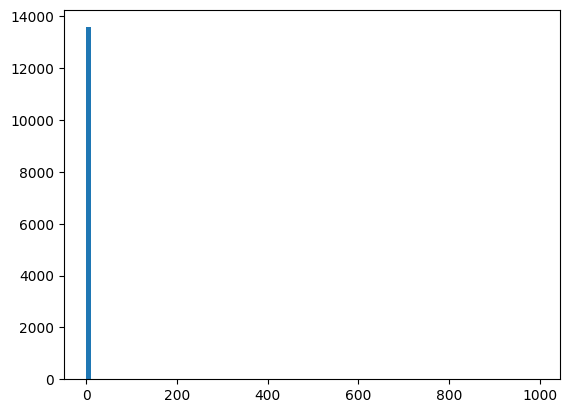

In [11]:
plt.hist(data['landmark_id'], 100, range = (0,994), label = 'test')

In [12]:
data['landmark_id'].between(5,10).sum()

69

In [13]:
print(df.columns)

Index(['id', 'url', 'landmark_id'], dtype='object')


[294. 316. 338. 334. 314. 306. 343. 333. 339. 356. 326. 360. 297. 303.
 340. 373. 297. 286. 322. 313. 341. 300. 328. 300. 301. 284. 310. 305.
 308. 305. 361. 340. 303. 293. 356. 329. 328. 296. 314. 314. 324. 350.
 388. 339. 331. 310. 318. 352. 332. 307.]
[     0.     4061.46   8122.92  12184.38  16245.84  20307.3   24368.76
  28430.22  32491.68  36553.14  40614.6   44676.06  48737.52  52798.98
  56860.44  60921.9   64983.36  69044.82  73106.28  77167.74  81229.2
  85290.66  89352.12  93413.58  97475.04 101536.5  105597.96 109659.42
 113720.88 117782.34 121843.8  125905.26 129966.72 134028.18 138089.64
 142151.1  146212.56 150274.02 154335.48 158396.94 162458.4  166519.86
 170581.32 174642.78 178704.24 182765.7  186827.16 190888.62 194950.08
 199011.54 203073.  ]
<BarContainer object of 50 artists>


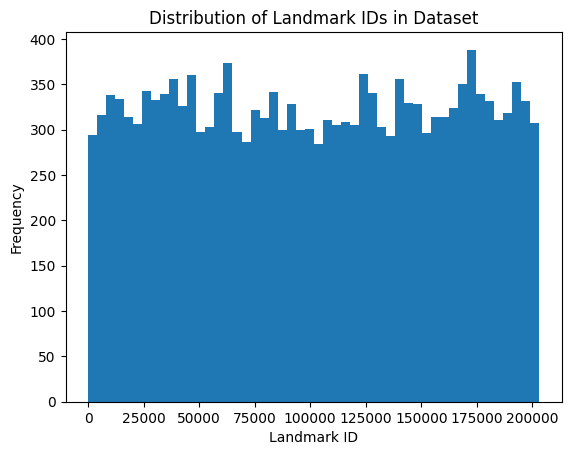

In [14]:
counts, bins, bars = plt.hist(df["landmark_id"], bins=50)

print(counts)
print(bins)
print(bars)

plt.xlabel("Landmark ID")
plt.ylabel("Frequency")
plt.title("Distribution of Landmark IDs in Dataset")
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

lencoder = LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [16]:
df.head()

,id,url,landmark_id
108,0036d78c05c194d9,https://upload.wikimedia.org/wikipedia/commons...,50089
172,00c08b162f34f53f,https://upload.wikimedia.org/wikipedia/commons...,163404
710,00e5d77c905d94a6,https://upload.wikimedia.org/wikipedia/commons...,26066
1256,00c8dba0df4d112a,https://upload.wikimedia.org/wikipedia/commons...,35744
1262,001cd787f1e9a803,https://upload.wikimedia.org/wikipedia/commons...,61937


In [17]:
def encode_label(lbl):
    return lencoder.transform(lbl)

In [18]:
def decode_label(lbl):
    return lencoder.inverse_transform(lbl)

In [19]:
def get_image_from_number(num):

    row = df.iloc[num]

    fname = row["id"]
    label = row["landmark_id"]

    fname = fname + ".jpg"

    f1 = fname[0]
    f2 = fname[1]
    f3 = fname[2]

    path = os.path.join(base_path, f1, f2, f3, fname)

    im = cv2.imread(path)

    if im is None:
        print("Image not found:", path)
        return np.zeros((224,224,3)), label

    return im, label

4 Sample images from random classes


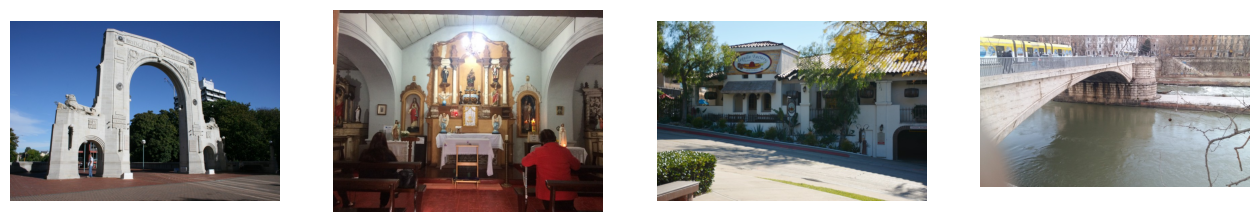

In [20]:
print("4 Sample images from random classes")

fig = plt.figure(figsize=(16,16))

all_images = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".jpg"):
            all_images.append(os.path.join(root, file))

sample_imgs = random.sample(all_images, 4)

for i, img_path in enumerate(sample_imgs, 1):
    img = np.array(Image.open(img_path))
    
    fig.add_subplot(1,4,i)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [21]:
from keras.applications.vgg19 import VGG19
from keras.layers import *
from keras.models import Sequential
import tensorflow as tf

In [22]:
learning_rate = 0.0001
decay_speed   = 1e-6
momentum      = 0.09
loss_function = "sparse_categorical_crossentropy"

source_model  = VGG19(weights=None)

drop_layer    = Dropout(0.5)
drop_layer2   = Dropout(0.5)

In [23]:
model = Sequential()

for layer in source_model.layers[:-1]:
    if layer == source_model.layers[-25]:
        model.add(BatchNormalization())
    model.add(layer)

model.add(Dense(num_classes, activation="softmax"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (BatchN  (None, 224, 224, 3)      12        
 ormalization)                                                   
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                        

In [24]:
from tensorflow.keras.optimizers import RMSprop

optim1 = RMSprop(learning_rate=learning_rate)

model.compile(
    optimizer=optim1,
    loss=loss_function,
    metrics=["accuracy"]
)

In [25]:
def image_reshape(im, target_size):
    return cv2.resize(im, target_size)

In [26]:
def get_batch(dataframe, start, batch_size):
    
    image_array = []
    label_array = []

    end_img = start + batch_size
    if end_img > len(dataframe):
        end_img = len(dataframe)

    for idx in range(start, end_img):
        n = idx
        im, label = get_image_from_number(n)
        im = image_reshape(im, (224, 224)) / 255.0

        image_array.append(im)
        label_array.append(label)

    label_array = encode_label(label_array)

    return np.array(image_array), np.array(label_array)

In [27]:
batch_size = 16
epoch_shuffle = True
weight_classes = True
epochs = 1

df = df.sample(frac=1).reset_index(drop=True)

split_index = int(0.8 * len(df))
train = df[:split_index].reset_index(drop=True)
val = df[split_index:].reset_index(drop=True)

print(len(train))
print(len(val))

12925
3232


In [29]:
X_train, y_train = get_batch(train, 0, 1000)

model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=epochs,
    shuffle=True
)

model.save("Model")

Image not found: ./images/0\0\e\00ee7114fb225595.jpg
Image not found: ./images/0\0\c\00c5b41595797913.jpg
Image not found: ./images/0\0\3\003c2751648ef34f.jpg
Image not found: ./images/0\0\e\00eed7091f984c17.jpg
Image not found: ./images/0\0\0\00079e673e2027be.jpg
Image not found: ./images/0\0\2\002df60847562b27.jpg
Image not found: ./images/0\0\c\00c290a8badbea4f.jpg
Image not found: ./images/0\0\3\00365cf8244ab0c8.jpg
Image not found: ./images/0\0\9\00921597b83b484f.jpg
Image not found: ./images/0\0\e\00e65bb80fe2dac2.jpg
Image not found: ./images/0\0\b\00be954bf0ac0ae2.jpg
Image not found: ./images/0\0\c\00c1ab2159c80af2.jpg
Image not found: ./images/0\0\a\00a67cf847485f09.jpg
Image not found: ./images/0\0\f\00fb835ae854214a.jpg
Image not found: ./images/0\0\6\00612975aae80627.jpg
Image not found: ./images/0\0\b\00b789c158534251.jpg
Image not found: ./images/0\0\f\00ff8b2d0e9aea2f.jpg
Image not found: ./images/0\0\7\00711fc312b927b0.jpg
Image not found: ./images/0\0\a\00a0b2aaba6a56

INFO:tensorflow:Assets written to: Model\assets


INFO:tensorflow:Assets written to: Model\assets


In [30]:
batch_size = 16

errors = 0
good_preds = []
bad_preds = []

for it in range(int(np.ceil(len(val) / batch_size))):

    X_val, y_val = get_batch(val, it * batch_size, batch_size)

    result = model.predict(X_val)
    cla = np.argmax(result, axis=1)

    for idx, res in enumerate(result):

        if cla[idx] != y_val[idx]:
            errors += 1
            bad_preds.append((batch_size * it + idx, cla[idx], res[cla[idx]]))
        else:
            good_preds.append((batch_size * it + idx, cla[idx], res[cla[idx]]))

print("Total errors:", errors)

Image not found: ./images/0\0\e\00ee7114fb225595.jpg
Image not found: ./images/0\0\c\00c5b41595797913.jpg
Image not found: ./images/0\0\3\003c2751648ef34f.jpg
Image not found: ./images/0\0\e\00eed7091f984c17.jpg
Image not found: ./images/0\0\0\00079e673e2027be.jpg
Image not found: ./images/0\0\2\002df60847562b27.jpg
Image not found: ./images/0\0\c\00c290a8badbea4f.jpg
Image not found: ./images/0\0\3\00365cf8244ab0c8.jpg
Image not found: ./images/0\0\9\00921597b83b484f.jpg
Image not found: ./images/0\0\e\00e65bb80fe2dac2.jpg
Image not found: ./images/0\0\b\00be954bf0ac0ae2.jpg
Image not found: ./images/0\0\c\00c1ab2159c80af2.jpg
Image not found: ./images/0\0\a\00a67cf847485f09.jpg
Image not found: ./images/0\0\f\00fb835ae854214a.jpg
Image not found: ./images/0\0\6\00612975aae80627.jpg
Image not found: ./images/0\0\b\00b789c158534251.jpg
1/1 [==============================] - 3s 3s/step
Image not found: ./images/0\0\f\00ff8b2d0e9aea2f.jpg
Image not found: ./images/0\0\7\00711fc312b927b0.